In [67]:
from sklearn.compose import TransformedTargetRegressor
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, ShuffleSplit, train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
import plotly.graph_objects as go
import plotly.io as pio

In [65]:

df_preprocessed= pd.read_csv('data/data_cleaned.csv')
# Log-transform target & continuous skewed vars
# returns the natural logarithm (base e) of 1 + x, where x is the argument. That is:
# ∀x>−1,𝙼𝚊𝚝𝚑.𝚕𝚘𝚐𝟷𝚙(𝚡)=ln(1+x)
#df_preprocessed['price'] = np.log1p(df_preprocessed['price'])
#df_preprocessed['habitablesurface'] = np.log1p(df_preprocessed['habitablesurface'])

features2 = ['bedroomcount','habitablesurface','haslift','hasgarden','hasswimmingpool','hasterrace',
             'price','hasparking','epcscore_encoded','buildingcondition_encoded','region_Brussels',
             'region_Flanders','region_Wallonia','type_encoded','latitude','longitude']

top_selected_features = ['price', 'habitablesurface', 'latitude', 'longitude', 
                         'buildingcondition_encoded'
                    ]

corr_with_price_features = ['price', 'habitablesurface', 'bedroomcount', 'hasparking', 'type_encoded']


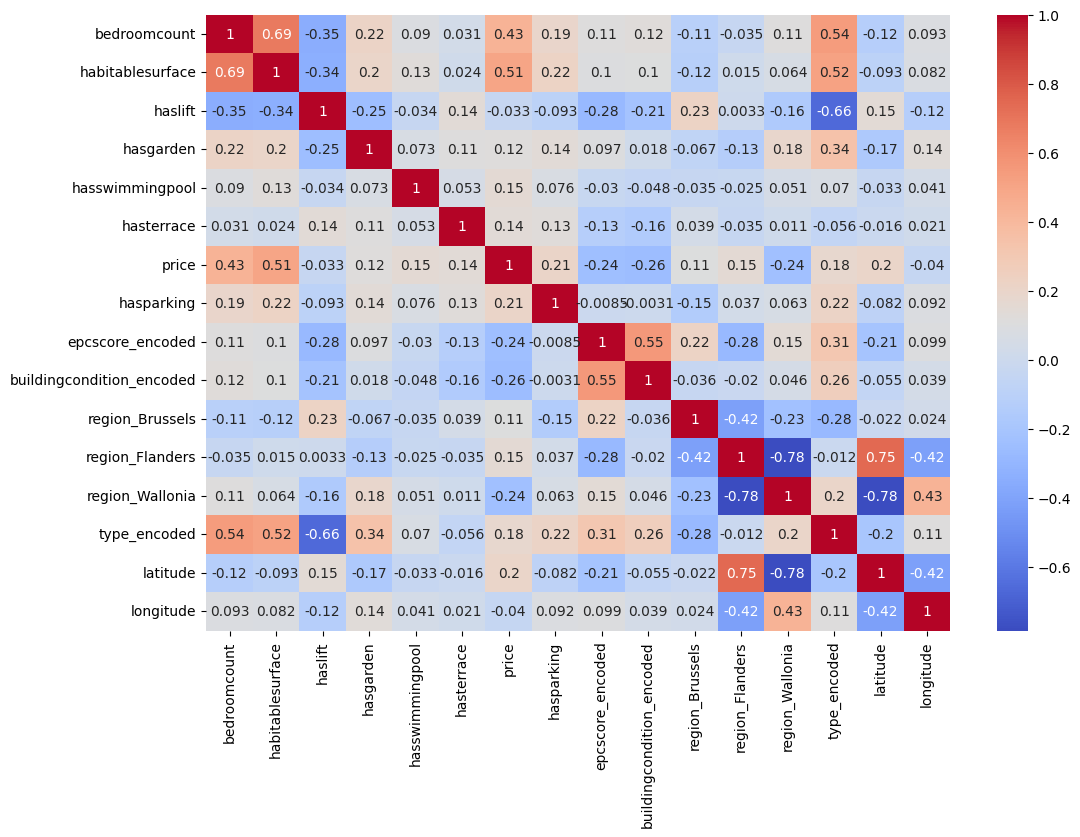

In [42]:
#corr = df_preprocessed[features + ['price']].corr()
corr = df_preprocessed[features2].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [68]:
X = df_preprocessed.drop("price", axis=1).values # numpy array
y = df_preprocessed["price"].values

#X = df_preprocessed[corr_with_price_features].drop("price", axis=1).values # numpy array
#y = df_preprocessed["price"].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3,
random_state=42)

# Recover feature names:
feature_names = df_preprocessed.drop("price", axis=1).columns.tolist()
#feature_names = df_preprocessed[top_selected_features].drop("price", axis=1).columns.tolist()
# Convert back to DataFrame:
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
print(X_scaled_df.columns)

Index(['bedroomcount', 'habitablesurface', 'haslift', 'hasgarden',
       'hasswimmingpool', 'hasterrace', 'hasparking', 'epcscore_encoded',
       'buildingcondition_encoded', 'region_Brussels', 'region_Flanders',
       'region_Wallonia', 'type_encoded', 'latitude', 'longitude'],
      dtype='object')


MSE : 13162627674.33
RMSE : 114728.50
MAE : 85012.68
R2 : 0.51


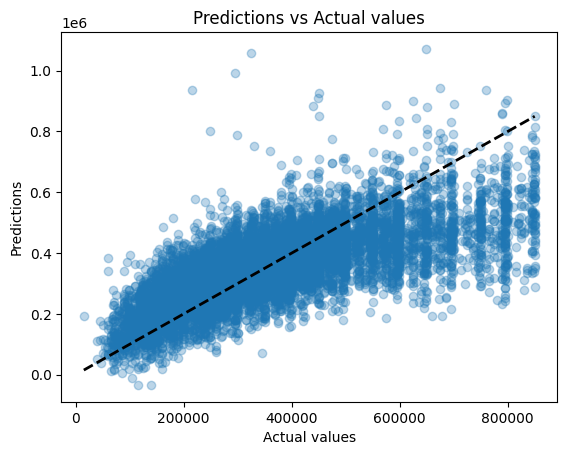

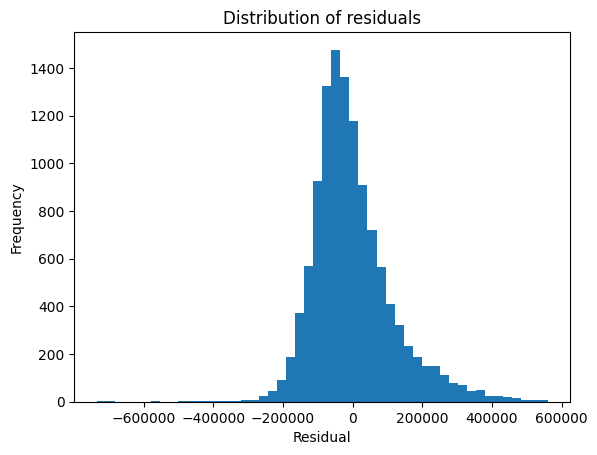

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2 : {r2:.2f}")

# Plot prediction vs actual value
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual values')
plt.show()

# Plot of residuals
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of residuals')
plt.show()



In [45]:
# Regularization
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'alpha': np.arange(0.0001, 1, 10),
"solver": ['sag', 'lsqr']}

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

#model = Ridge(alpha=1.0)  # or Lasso(alpha=0.1)
model = Ridge()
#scores=cross_val_score(model, X_scaled, y, cv=cv)
scores=RandomizedSearchCV(model, param_grid, cv=cv, n_iter=2)
print(f"Cross-val scores: {scores}")
#print(f"Mean CV score: {scores.mean():.2f}")

# Fit on training data
model.fit(X_train, y_train)

# Score on test data
score = model.score(X_test, y_test)
print(f"R² score with Ridge: {score:.2f}")

y_pred = model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print(f'MSE:{mse:.2f}')
rmse=root_mean_squared_error(y_test, y_pred)
print(f'The RMSE:{rmse:.2f}')

mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
print(f'MAE: {mae:.2f}')
print(f'Explained Variance: {evs:.2f}')


Cross-val scores: RandomizedSearchCV(cv=ShuffleSplit(n_splits=5, random_state=42, test_size=0.2, train_size=None),
                   estimator=Ridge(), n_iter=2,
                   param_distributions={'alpha': array([0.0001]),
                                        'solver': ['sag', 'lsqr']})
R² score with Ridge: 0.51
MSE:13162636330.52
The RMSE:114728.53
MAE: 85012.76
Explained Variance: 0.51


In [46]:
# consider adjusting max_depth, n_estimators, by cross-validation
# increasing training data

# Initial model
model = RandomForestRegressor(max_depth=20, n_estimators=100, random_state=42)

# Fit on training data
model.fit(X_train, y_train)

# Score on test data
score = model.score(X_test, y_test)
print(f"R² score with Random Forest Regressor: {score:.2f}")

y_pred = model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print(f'MSE:{mse:.2f}')
rmse=root_mean_squared_error(y_test, y_pred)
print(f'The RMSE:{rmse:.2f}')

mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
print(f'MAE: {mae:.2f}')
print(f'Explained Variance: {evs:.2f}')

# CV score
scores = cross_val_score(model, X_scaled, y, cv=cv)
print(f"Cross-val scores: {scores}")
print(f"Mean CV score: {scores.mean():.2f}")

# hyperparams
"""param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.75, 1.0]
}


# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    cv=cv,
    n_iter=20,  
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)


print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.2f}")

# Evaluate best model
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
r2 = best_model.score(X_test, y_test)

print(f"R² score: {r2:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Explained Variance: {evs:.2f}")"""

R² score with Random Forest Regressor: 0.71
MSE:7888630226.10
The RMSE:88817.96
MAE: 63363.80
Explained Variance: 0.71
Cross-val scores: [0.70883879 0.7156784  0.71552371 0.72262718 0.70709495]
Mean CV score: 0.71


'param_grid = {\n    \'n_estimators\': [100, 200, 500],\n    \'max_depth\': [10, 20, 30, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'max_features\': [\'sqrt\', \'log2\', 0.5, 0.75, 1.0]\n}\n\n\n# Create the RandomizedSearchCV object\nrandom_search = RandomizedSearchCV(\n    estimator=model,\n    param_distributions=param_grid,\n    cv=cv,\n    n_iter=20,  \n    random_state=42,\n    n_jobs=-1\n)\n\n# Fit\nrandom_search.fit(X_train, y_train)\n\n\nprint(f"Best Params: {random_search.best_params_}")\nprint(f"Best CV Score: {random_search.best_score_:.2f}")\n\n# Evaluate best model\nbest_model = random_search.best_estimator_\n\ny_pred = best_model.predict(X_test)\nmse = mean_squared_error(y_test, y_pred)\nrmse = np.sqrt(mse)\nmae = mean_absolute_error(y_test, y_pred)\nevs = explained_variance_score(y_test, y_pred)\nr2 = best_model.score(X_test, y_test)\n\nprint(f"R² score: {r2:.2f}")\nprint(f"MSE: {mse:.2f}")\nprint(f"RMSE: {rmse:.2f}")\nprin

In [47]:
#RandomizedSearchCV , LightGBM 

In [48]:
"""for feat, imp in sorted(zip(X_scaled_df.columns, model.feature_importances_)):
    print(f"{feat}: {imp:.6f}")
    
print(len(X_scaled_df.columns))
print(len(model.feature_importances_))"""

'for feat, imp in sorted(zip(X_scaled_df.columns, model.feature_importances_)):\n    print(f"{feat}: {imp:.6f}")\n\nprint(len(X_scaled_df.columns))\nprint(len(model.feature_importances_))'

In [49]:
#Optuna

In [ ]:
"""fig = go.Figure(go.Bar(
            x=model.feature_importances_,
            y=X_scaled_df.columns,
            orientation='h', marker_color='steelblue'))
fig.update_layout(template='plotly_dark', title='<b>Estimating feature importance through the Random Forest model', title_x=0.5, 
                 xaxis_title="Feature importance", yaxis_title='Feature')

fig.show()"""

#pio.renderers.default = 'browser'
pio.renderers.default = 'notebook+jupyterlab'

# Get importances and feature names
importances = model.feature_importances_
feature_names = X_scaled_df.columns

# Sort indices in ascending order
sorted_idx = np.argsort(importances) # [::-1]

# Sort values and names
importances_sorted = importances[sorted_idx]
feature_names_sorted = feature_names[sorted_idx]

# Plot
fig = go.Figure(go.Bar(
    x=importances_sorted,
    y=feature_names_sorted,
    orientation='h',
    marker_color='steelblue'
))

fig.update_layout(
    template='plotly_dark',
    title='<b>Estimating feature importance through the Random Forest model',
    title_x=0.5,
    xaxis_title="Feature importance",
    yaxis_title='Feature'
)

fig.show()

In [ ]:
df_models = pd.DataFrame(data=None, columns=['Model Name', 'R2 train', 'R2 test',
                                             'RMSE train', 'RMSE test',
                                           'MAE train', 'MAE test',
                                           'EVS train', 'EVS test', 'CV mean score'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

degree=2
models = [
    (make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    ), 'LinearRegression/Polynomial'),
    (Ridge(), 'Ridge'),
    (Lasso(), 'Lasso'),
    (ElasticNet(), 'ElasticNet'),
    (GradientBoostingRegressor(), 'GradientBoosting'),
    (RandomForestRegressor(n_estimators=150, random_state=42), 'RandomForest'),
    (XGBRegressor(eval_metric='rmse', use_label_encoder=False, random_state=42), 'XGBoost'),
    (CatBoostRegressor(iterations=500, random_seed=42, learning_rate=0.5, depth=6, verbose=0), 'CatBoost Regressor')
]

for base_model, name in models:
    model = make_pipeline(
        StandardScaler(),
        base_model
    )

    regr = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    evs_train = explained_variance_score(y_train, y_pred_train)
    evs_test = explained_variance_score(y_test, y_pred_test)

    # score CV
    cv_scores = cross_val_score(regr, X, y, cv=kf, scoring='r2')
    cv_score_mean = cv_scores.mean()

    df_models.loc[len(df_models.index)] = [
        name,
        f'{r2_train:.2f}', f'{r2_test:.2f}',
        f'{rmse_train:.0f}€', f'{rmse_test:.0f}€',
        f'{mae_train:.0f}€', f'{mae_test:.0f}€',
        f'{evs_train:.2f}', f'{evs_test:.2f}',
        f'{cv_score_mean:.2f}'
    ]

print(df_models)



# Plot R2 train/test as before
fig = go.Figure(data=[
    go.Bar(name='R2 Train', x=df_models.Algorithm, y=df_models.r2_train),
    go.Bar(name='R2 Test', x=df_models.Algorithm, y=df_models.r2_test)
])
fig.update_layout(template='plotly_dark', title='R2 Scores for Train and Test Sets', title_x=0.5)
fig.show()



"""def make_model(X_tr, X_te, y_tr, y_te, model, model_name: str): 
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    r2_train = r2_score(y_tr, y_pred_train)
    r2_test = r2_score(y_te, y_pred_test)
    df_models.loc[len(df_models.index)] = [model_name, r2_train, r2_test]
                       

make_model(X_train, X_test, y_train, y_test, LinearRegression(), 'LinearRegression')
make_model(X_train, X_test, y_train, y_test, Ridge(), 'Ridge')
make_model(X_train, X_test, y_train, y_test, Lasso(), 'Lasso')
make_model(X_train, X_test, y_train, y_test, ElasticNet(), 'ElasticNet')
make_model(X_train, X_test, y_train, y_test, GradientBoostingRegressor(), 'GradientBoosting')
make_model(X_train, X_test, y_train, y_test, RandomForestRegressor(), 'RandomForest')
make_model(X_train, X_test, y_train, y_test, XGBRegressor(), 'XGBoost')

"""

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:08:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:08:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:08:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:08:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\xgboost

                    Model Name R2 train R2 test RMSE train RMSE test  \
0  LinearRegression/Polynomial     0.61    0.60    103326€   103641€   
1                        Ridge     0.37    0.42    131641€   125088€   
2                        Lasso    -0.05   -0.05    169431€   168385€   
3                   ElasticNet    -0.05   -0.05    169431€   168385€   
4             GradientBoosting     0.68    0.66     93417€    95342€   
5                 RandomForest     0.95    0.71     35501€    88808€   
6                      XGBoost     0.82    0.73     71007€    85652€   
7           CatBoost Regressor     0.84    0.73     65441€    85487€   

  MAE train MAE test EVS train EVS test CV mean score  
0    72474€   72668€      0.61     0.61          0.60  
1    85655€   85411€      0.37     0.43          0.37  
2   127429€  126643€      0.00     0.00         -0.05  
3   127429€  126643€      0.00     0.00         -0.05  
4    66729€   67908€      0.69     0.67          0.67  
5    23506€   6

AttributeError: 'DataFrame' object has no attribute 'Algorithm'

In [52]:
fig = go.Figure(data=[
    go.Bar(name='r2_train', x=df_models.Algorithm, y=df_models.r2_train),
    go.Bar(name='r2_test', x=df_models.Algorithm, y=df_models.r2_test)
])
fig.update_layout(template='plotly_dark', title='R2 for train and test', title_x=0.5)

In [53]:
X_trainval, X_valid, y_trainval, y_valid = train_test_split(X_train, y_train, shuffle=True,  random_state=42)


In [54]:
import optuna

def objective(trial):
    #'tree_method':'gpu_hist',  # this parameter means using the GPU when training our model to speedup the training process
    param = {
        'sampling_method': 'uniform', #'gradient_based'
        'lambda': trial.suggest_loguniform('lambda', 7.0, 17.0),
        'alpha': trial.suggest_loguniform('alpha', 7.0, 17.0),
        'eta': trial.suggest_categorical('eta', [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        'gamma': trial.suggest_categorical('gamma', [18, 19, 20, 21, 22, 23, 24, 25]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.008,0.01,0.012,0.014,0.016,0.018, 0.02]),
        #"colsample_by_tree" is the fraction of features (randomly selected) that will be used to train each tree.
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]),
        #random subsample of columns based on every split (left or right swerve). So, every level may have 2 different subsamples if this level has left and right split. 
        'colsample_bynode': trial.suggest_categorical('colsample_bynode', [0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]),
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 8, 600),  
        'max_depth': trial.suggest_categorical('max_depth', [3, 4, 5, 6, 7]),  
        #"subsample" is the fraction of the training samples (randomly selected) that will be used to train each tree.
        'subsample': trial.suggest_categorical('subsample', [0.5,0.6,0.7,0.8,1.0]),
        'random_state': 42
    }

    model = XGBRegressor(**param)  
    
    model.fit(X_trainval, y_trainval, eval_set=[(X_valid, y_valid)], verbose=False)
    
    predict = model.predict(X_valid)
    
    r_2 = r2_score(predict, y_valid)
    
    return r_2


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50,  timeout=600)
    
print("Number of finished trials: {}".format(len(study.trials)))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

[I 2025-07-01 08:41:49,670] A new study created in memory with name: no-name-421746db-43ab-47a1-9433-7704238a6709
C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_14460\3083501541.py:7: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_14460\3083501541.py:8: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2025-07-01 08:41:50,518] Trial 0 finished with value: 0.4849230760795873 and parameters: {'lambda': 7.888079142

Number of finished trials: 50
Best trial:
  Value: 0.6541334752538863
  Params: 
    lambda: 12.942300976033637
    alpha: 12.9330220277206
    eta: 0.7
    gamma: 20
    learning_rate: 0.02
    colsample_bytree: 0.7
    colsample_bynode: 0.5
    n_estimators: 843
    min_child_weight: 11
    max_depth: 7
    subsample: 0.8


In [55]:
fig = optuna.visualization.plot_slice(study)
fig.update_layout(template='plotly_dark', title='<b>Slice Plot', title_x=0.2)

In [56]:
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(template='plotly_dark', title='<b>Optimization History Plot', title_x=0.5)

In [57]:
fig = optuna.visualization.plot_param_importances(study)
fig.update_layout(template='plotly_dark', title='<b>Hyperparameter Importances', title_x=0.5)


In [58]:
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,0.5
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [59]:
print(f'Best model result in Test: {r2_score(y_test, best_model.predict(X_test))}')
print(f'Best model result in Train: {r2_score(y_train, best_model.predict(X_train))}')

Best model result in Test: 0.7428529499686247
Best model result in Train: 0.7960447126244644


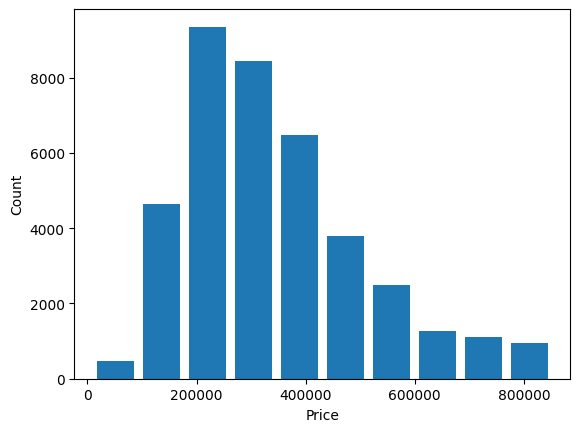

In [60]:
plt.hist(df_preprocessed.price, rwidth=0.8)
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_14460\3456620643.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




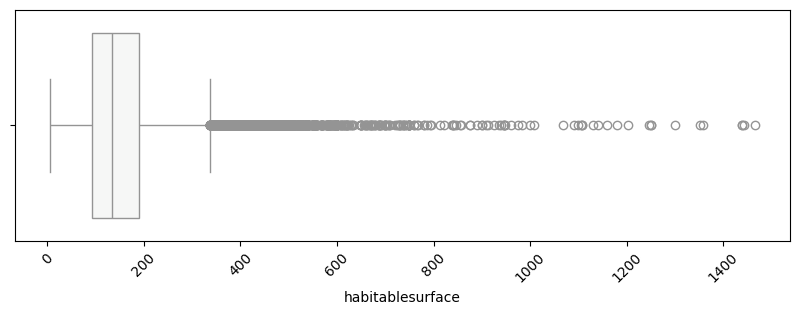

np.float64(1465.0)

In [61]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 3))

#df1 = df.groupby('type')['apartment'].apply(list).reset_index(name='new')
sns.boxplot(data=df_preprocessed, x='habitablesurface', width=0.8, palette="PRGn")
ax.tick_params(axis='x', rotation=45)
plt.show()

df_preprocessed['habitablesurface'].max()



In [62]:
from sklearn.metrics import classification_report, confusion_matrix
knn = KNeighborsClassifier(n_neighbors=7)

X = df_preprocessed.drop("price", axis=1).values
y = df_preprocessed["price"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

"""print(np.mean(X), np.std(X))
print(np.mean(X_train_scaled), np.std(X_train_scaled))"""



"""models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),
"Decision Tree": DecisionTreeClassifier()}
results = []
for model in models.values():
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.show()"""

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

      9000.0       0.00      0.00      0.00         0
     14999.0       0.00      0.00      0.00         1
     35000.0       0.00      0.00      0.00         0
     40000.0       0.00      0.00      0.00         2
     45000.0       0.00      0.00      0.00         2
     47000.0       0.00      0.00      0.00         1
     49000.0       0.00      0.00      0.00         0
     50000.0       0.00      0.00      0.00         2
     55000.0       0.07      0.50      0.12         2
     56000.0       0.00      0.00      0.00         0
     57000.0       0.00      0.00      0.00         1
     59000.0       0.00      0.00      0.00         1
     59500.0       0.00      0.00      0.00         1
     59594.0       0.00      0.00      0.00         1
     59999.0       0.00      0.00      0.00         1
     60000.0   

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Emmanuel\challenge-regression\mle\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `

'models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),\n"Decision Tree": DecisionTreeClassifier()}\nresults = []\nfor model in models.values():\n    kf = KFold(n_splits=6, random_state=42, shuffle=True)\n    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)\n    results.append(cv_results)\nplt.boxplot(results, labels=models.keys())\nplt.show()'

In [63]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
X = df_two_features.drop("price", axis=1).values
y = df_two_features["price"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
y_pred_probs = logreg.predict_proba(X_test_scaled)[:, 1]
print(y_pred_probs[0])

NameError: name 'df_two_features' is not defined